# Классификация типа здания

Изучаются датасеты AID и RESISC45: 4 класса, баланс и качество данных.

**Классы:**
- `commercial` — коммерческая застройка
- `industrial` — промышленная
- `dense_residential` — плотная жилая
- `sparse_residential` — редкая жилая

## Распределение классов (баланс)

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
from PIL import Image

sys.path.insert(0, str(Path('..').resolve() / 'src'))

from dataset import IMAGE_EXTENSIONS, build_combined_dataframe, CLASSES
from utils import DATA_ROOT, EDA, RANDOM_SEED

plt.rcParams['figure.figsize'] = EDA.figure_size
plt.rcParams['font.size'] = EDA.font_size

raw_df = build_combined_dataframe(DATA_ROOT)
records = []
broken = []

for _, row in raw_df.iterrows():
    path = Path(row['path'])
    cls = row['class']
    try:
        with Image.open(path) as img:
            img.verify()
        with Image.open(path) as img:
            w, h = img.size
            mode = img.mode
        records.append({
            'path': str(path),
            'filename': path.name,
            'class': cls,
            'source': row['source'],
            'width': w,
            'height': h,
            'mode': mode,  # режим цвета PIL (RGB и т.п.)
        })
    except Exception as e:
        broken.append({'path': str(path), 'class': cls, 'error': str(e)})

df = pd.DataFrame(records)
broken_df = pd.DataFrame(broken)

class_counts = df['class'].value_counts().reindex(CLASSES)

col_width = max(len(cls) for cls in CLASSES)
print(f'{"Класс":<{col_width}}\t\t\tКоличество')
for cls in CLASSES:
    print(f'{cls:<{col_width}}\t\t\t{class_counts[cls]}')

print(f'\nВсего: {len(df)}')
print('\nПо датасетам:')
print(df.groupby(['source', 'class']).size().unstack(fill_value=0))

Класс             			Количество
commercial        			777
industrial        			831
dense_residential 			809
sparse_residential			722

Всего: 3139

По датасетам:
class          commercial  dense_residential  industrial  sparse_residential
source                                                                      
AID                   350                410         390                 293
NWPU-RESISC45         427                399         441                 429


## Примеры изображений по классам

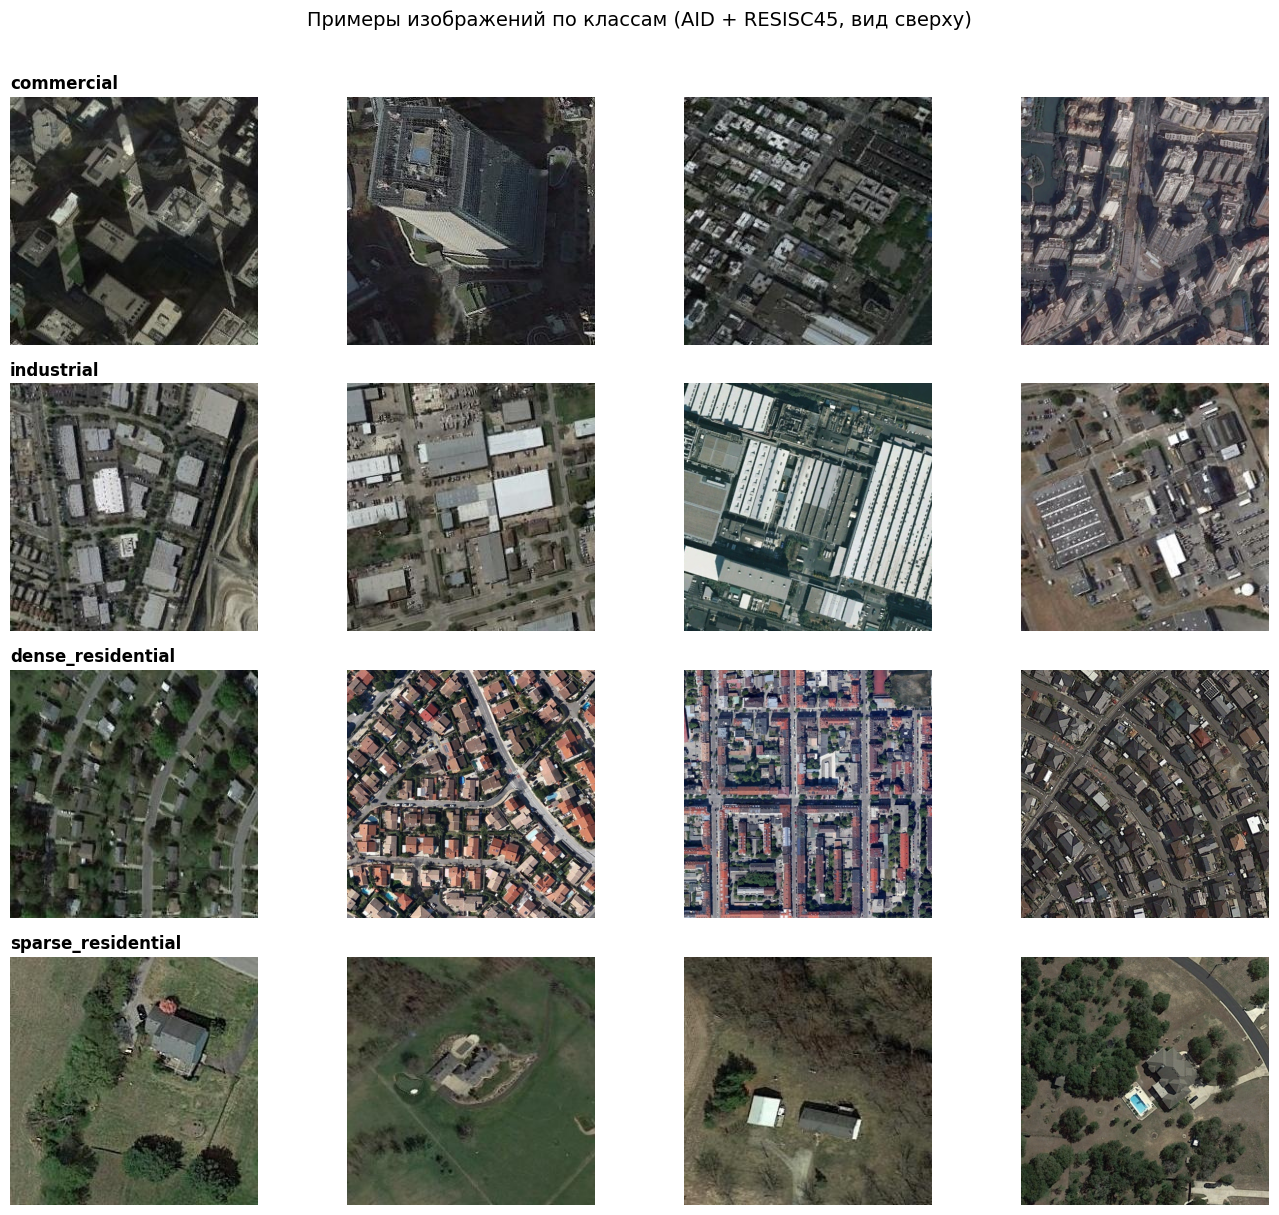

In [2]:
fig, axes = plt.subplots(
    len(CLASSES), EDA.samples_per_class,
    figsize=(EDA.subplot_width, EDA.subplot_height_per_class * len(CLASSES)),
)

for row, cls in enumerate(CLASSES):
    cls_paths = df[df['class'] == cls]['path'].sample(
        EDA.samples_per_class, random_state=RANDOM_SEED
    ).tolist()
    for col, p in enumerate(cls_paths):
        img = Image.open(p)
        axes[row, col].imshow(img)
        axes[row, col].axis('off')
        if col == 0:
            axes[row, col].set_title(cls, loc='left', fontsize=12, fontweight='bold')

plt.suptitle('Примеры изображений по классам (AID + RESISC45, вид сверху)', y=1.01, fontsize=14)
plt.tight_layout()
plt.show()

## Выводы

1. **Баланс классов** — данные AID + RESISC45; лёгкий дисбаланс между классами.
2. **Размеры** — AID: 600×600, цветные; RESISC45: 256×256, цветные. Битых файлов не найдено.
3. **Похожие классы** — `dense_residential`, `industrial` и `commercial`.
4. **Вероятные места возникновения ошибок** — в некоторых случаях `dense_residential` похож на `industrial` упорядоченностью построек. В части фото класса `commercial` наблюдается жилая застройка (`dense_residential`).